In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

SEED = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_DIR = Path("../data")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

print("Train:", TRAIN_PATH)
print("Test:", TEST_PATH)
print("Sample submission:", SUBMISSION_PATH)

Train: ..\data\train.csv
Test: ..\data\test.csv
Sample submission: ..\data\sample_submission.csv


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (7613, 5)
Test shape: (3263, 4)
Sample submission shape: (3263, 2)


In [4]:
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
print("Training columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

print("\nTraining dataset info:")
train_df.info()

Training columns: ['id', 'keyword', 'location', 'text', 'target']
Test columns: ['id', 'keyword', 'location', 'text']

Training dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [6]:
missing_values = train_df.isnull().sum()
missing_percentage = (train_df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_df

,Missing Values,Percentage (%)
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


In [7]:
target_counts = train_df["target"].value_counts().sort_index()
target_percentage = (
    train_df["target"].value_counts(normalize=True).sort_index() * 100
).round(2)

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percentage
})

target_distribution

,Count,Percentage (%)
target,,
0,4342,57.03
1,3271,42.97


In [8]:
print("Duplicate rows:", train_df.duplicated().sum())
print("Duplicate tweet texts:", train_df["text"].duplicated().sum())

Duplicate rows: 0
Duplicate tweet texts: 110


In [9]:
print("NON-DISASTER TWEETS\n")

for text in train_df.loc[train_df["target"] == 0, "text"].head(5):
    print("-", text)

print("\nDISASTER TWEETS\n")

for text in train_df.loc[train_df["target"] == 1, "text"].head(5):
    print("-", text)

NON-DISASTER TWEETS

- What's up man?
- I love fruits
- Summer is lovely
- My car is so fast
- What a goooooooaaaaaal!!!!!!

DISASTER TWEETS

- Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
- Forest fire near La Ronge Sask. Canada
- All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
- 13,000 people receive #wildfires evacuation orders in California 
- Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 


In [10]:
train_df["char_count"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["char_count", "word_count"]].describe()

,char_count,word_count
count,7613.000000,7613.000000
mean,101.037436,14.903586
std,33.781325,5.732604
min,7.000000,1.000000
25%,78.000000,11.000000
50%,107.000000,15.000000
75%,133.000000,19.000000
max,157.000000,31.000000


In [11]:
train_df.groupby("target")[["char_count", "word_count"]].mean().round(2)

,char_count,word_count
target,,
0,95.71,14.70
1,108.11,15.17


In [12]:
duplicate_texts = train_df[
    train_df.duplicated(subset="text", keep=False)
].sort_values("text")

duplicate_texts[
    ["id", "keyword", "location", "text", "target"]
].head(20)

,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it...,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it...,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it...,1
6363,9095,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6373,9107,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6377,9113,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6378,9114,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6392,9135,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6366,9098,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
2828,4064,displaced,NaN,#KCA #VoteJKT48ID 12News: UPDATE: A family of ...,1


In [13]:
print("Rows with duplicated text:", len(duplicate_texts))
print("Unique duplicated texts:", duplicate_texts["text"].nunique())

Rows with duplicated text: 179
Unique duplicated texts: 69


In [14]:
label_counts_per_text = train_df.groupby("text")["target"].nunique()

conflicting_texts = label_counts_per_text[
    label_counts_per_text > 1
].index

print("Texts with conflicting labels:", len(conflicting_texts))

Texts with conflicting labels: 18


In [15]:
train_df[
    train_df["text"].isin(conflicting_texts)
][["text", "target", "keyword", "location"]].sort_values("text")

,text,target,keyword,location
4290,#Allah describes piling up #wealth thinking it...,0,hellfire,"Jubail IC, Saudi Arabia."
4299,#Allah describes piling up #wealth thinking it...,0,hellfire,?????? ??? ?????? ????????
4312,#Allah describes piling up #wealth thinking it...,1,hellfire,?????? ???? ??????
4244,#foodscare #offers2go #NestleIndia slips into ...,0,hazardous,"New Delhi, Delhi"
4221,#foodscare #offers2go #NestleIndia slips into ...,1,hazardous,NaN
4239,#foodscare #offers2go #NestleIndia slips into ...,1,hazardous,"Mysore, Karnataka"
2832,.POTUS #StrategicPatience is a strategy for #G...,0,displaced,Pedophile hunting ground
2831,.POTUS #StrategicPatience is a strategy for #G...,1,displaced,Pedophile hunting ground
2830,.POTUS #StrategicPatience is a strategy for #G...,1,displaced,Pedophile hunting ground
2833,.POTUS #StrategicPatience is a strategy for #G...,1,displaced,Pedophile hunting ground


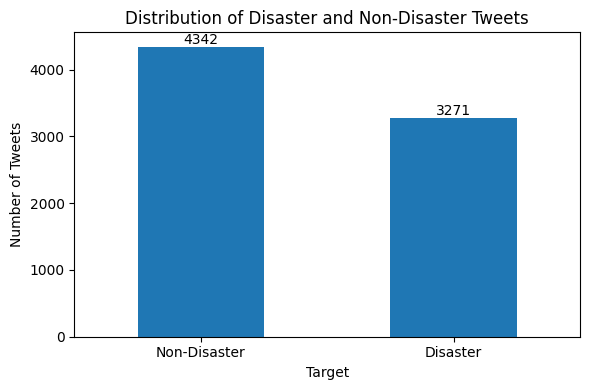

In [16]:
ax = target_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Distribution of Disaster and Non-Disaster Tweets")
plt.xlabel("Target")
plt.ylabel("Number of Tweets")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Disaster", "Disaster"],
    rotation=0
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

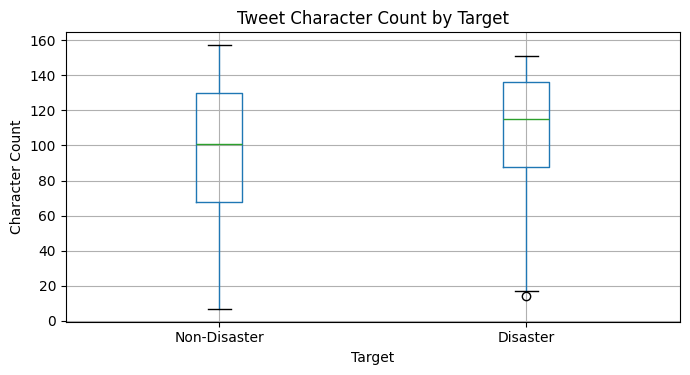

In [17]:
train_df.boxplot(
    column="char_count",
    by="target",
    figsize=(7, 4)
)

plt.title("Tweet Character Count by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Character Count")
plt.xticks(
    ticks=[1, 2],
    labels=["Non-Disaster", "Disaster"]
)

plt.tight_layout()
plt.show()